# **Dataset Download and Setup**

kaggle linking for dowloading dataset

In [ ]:
import kagglehub

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [ ]:
import os
os.makedirs('/root/.kaggle', exist_ok=True)
!mv kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [ ]:
import kagglehub

path = kagglehub.dataset_download("vulamnguyen/rwf2000")
print(path)

Using Colab cache for faster access to the 'rwf2000' dataset.
/kaggle/input/rwf2000


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


printing struture of file in leveled way


In [ ]:
import os

base = "/kaggle/input/rwf2000"
for root, dirs, files in os.walk(base):
    level = root.replace(base, "").count(os.sep)
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    if files:
        print(f"{indent}  → {len(files)} files")

rwf2000/
  RWF-2000/
    val/
      Fight/
        → 200 files
      NonFight/
        → 200 files
    train/
      Fight/
        → 800 files
      NonFight/
        → 800 files


the actual file name is soo long hence making it short

In [ ]:
import os
import shutil
import hashlib
import csv

src_base = "/kaggle/input/rwf2000"
out_dir = "/content/RWF-2000"
os.makedirs(out_dir, exist_ok=True)

mapping = []
video_exts = (".avi", ".mp4")

for root, dirs, files in os.walk(src_base):
    for fname in files:
        if not fname.lower().endswith(video_exts):
            continue

        src_path = os.path.join(root, fname)
        ext = os.path.splitext(fname)[1]

        # relative subfolder (preserves train/Fight, val/NonFight etc)
        rel_subfolder = os.path.relpath(root, src_base)

        short_name = hashlib.md5(src_path.encode()).hexdigest()[:16] + ext

        target_dir = os.path.join(out_dir, rel_subfolder)
        os.makedirs(target_dir, exist_ok=True)

        target_path = os.path.join(target_dir, short_name)
        shutil.copyfile(src_path, target_path)

        mapping.append({"original": src_path, "new_path": target_path})

with open(os.path.join(out_dir, "filename_mapping.csv"), "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["original", "new_path"])
    writer.writeheader()
    writer.writerows(mapping)

print(f"Copied {len(mapping)} video files.")

Copied 2000 video files.


checking if all file exist or not !

In [ ]:
import glob
all_files = glob.glob("/content/RWF-2000/**/*.avi", recursive=True) + glob.glob("/content/RWF-2000/**/*.mp4", recursive=True)
print("Total video files:", len(all_files))

Total video files: 2000


downloading ultralytics package for yolo

In [ ]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 31.6 MB/s eta 0:00:00


# **Pose Model Sanity Check (single video)**

In [ ]:
import pandas as pd

mapping = pd.read_csv("/content/RWF-2000/filename_mapping.csv")

# match folders that are exactly ".../Fight/..." not ".../NonFight/..."
fight_rows = mapping[mapping["original"].str.contains("/Fight/", regex=False)]

print("Fight videos found:", len(fight_rows))
sample_row = fight_rows.iloc[0]
sample_video_path = sample_row["new_path"]

print("Original name:", sample_row["original"])
print("Using file:", sample_video_path)

Fight videos found: 1000
Original name: /kaggle/input/rwf2000/RWF-2000/val/Fight/JECBfnp2ZXc_2.avi
Using file: /content/RWF-2000/RWF-2000/val/Fight/17afcca356c60425.avi


Using Yolo 11 pose model


In [ ]:
from ultralytics import YOLO

pose_model = YOLO("yolo11n-pose.pt")  # auto-downloads weights first run

results = pose_model.predict(
    source=sample_video_path,
    conf=0.4,
    save=True  # saves an annotated output video so you can visually verify
)

upto this our model can easily detect the person based on the 17 keypoints of human body

In [ ]:
import glob

output_videos = glob.glob("/content/runs/pose/predict*/*.avi") + glob.glob("/content/runs/pose/predict*/*.mp4")
print(output_videos)

['/content/runs/pose/predict/17afcca356c60425.avi']


the code below confirms YOLOv11 pose n output format

In [ ]:
first_result = results[0]

print("Number of people detected in frame 1:", len(first_result.keypoints))
print("Keypoints shape:", first_result.keypoints.xy.shape)  # (num_people, 17, 2)
print("Confidence shape:", first_result.keypoints.conf.shape)  # (num_people, 17)

print("\nSample keypoints for person 0:")
print(first_result.keypoints.xy[0])

Number of people detected in frame 1: 2
Keypoints shape: torch.Size([2, 17, 2])
Confidence shape: torch.Size([2, 17])

Sample keypoints for person 0:
tensor([[1054.5701,  174.3817],
        [1052.2274,  165.6134],
        [1051.8267,  165.5006],
        [1025.3280,  172.1997],
        [1056.5952,  176.5317],
        [1014.1423,  216.3601],
        [1071.1541,  221.6701],
        [ 987.2711,  262.5716],
        [1089.0813,  256.3507],
        [1000.7555,  285.2595],
        [1087.3104,  234.1469],
        [1006.2649,  312.0818],
        [1050.9668,  315.2922],
        [ 973.3769,  337.9638],
        [1051.5393,  352.0120],
        [ 942.2962,  396.3308],
        [1058.0782,  416.0502]], device='cuda:0')


In [ ]:
results = pose_model.predict(
    source=sample_video_path,
    conf=0.4,
    save=False,
    stream=True  # memory-efficient — processes frame by frame instead of loading all at once
)

In [ ]:
import numpy as np

all_frames_data = []

for frame_idx, result in enumerate(results):
    if result.keypoints is None or len(result.keypoints) == 0:
        # no people detected this frame
        all_frames_data.append(np.zeros((0, 17, 3)))
        continue

    xy = result.keypoints.xy.cpu().numpy()      # (num_people, 17, 2)
    conf = result.keypoints.conf.cpu().numpy()  # (num_people, 17)

    # combine into (num_people, 17, 3) -> x, y, confidence
    combined = np.concatenate([xy, conf[..., None]], axis=-1)
    all_frames_data.append(combined)

print("Total frames processed:", len(all_frames_data))
print("Frame 0 shape:", all_frames_data[0].shape)
print("People detected per frame (first 10 frames):", [f.shape[0] for f in all_frames_data[:10]])


video 1/1 (frame 1/150) /content/RWF-2000/RWF-2000/val/Fight/17afcca356c60425.avi: 384x640 2 persons, 12.6ms
video 1/1 (frame 2/150) /content/RWF-2000/RWF-2000/val/Fight/17afcca356c60425.avi: 384x640 2 persons, 11.8ms
video 1/1 (frame 3/150) /content/RWF-2000/RWF-2000/val/Fight/17afcca356c60425.avi: 384x640 3 persons, 11.5ms
video 1/1 (frame 4/150) /content/RWF-2000/RWF-2000/val/Fight/17afcca356c60425.avi: 384x640 2 persons, 11.4ms
video 1/1 (frame 5/150) /content/RWF-2000/RWF-2000/val/Fight/17afcca356c60425.avi: 384x640 2 persons, 11.5ms
video 1/1 (frame 6/150) /content/RWF-2000/RWF-2000/val/Fight/17afcca356c60425.avi: 384x640 3 persons, 14.1ms
video 1/1 (frame 7/150) /content/RWF-2000/RWF-2000/val/Fight/17afcca356c60425.avi: 384x640 2 persons, 16.4ms
video 1/1 (frame 8/150) /content/RWF-2000/RWF-2000/val/Fight/17afcca356c60425.avi: 384x640 2 persons, 16.1ms
video 1/1 (frame 9/150) /content/RWF-2000/RWF-2000/val/Fight/17afcca356c60425.avi: 384x640 2 persons, 21.0ms
video 1/1 (frame 1

so it make numpy file for each frame of a one video and saves it.

In [ ]:
import os

os.makedirs("/content/pose_sequences_raw", exist_ok=True)

# save as an object array since frame shapes vary
np.save(
    "/content/pose_sequences_raw/sample_fight_001.npy",
    np.array(all_frames_data, dtype=object)
)

print("Saved.")

Saved.


In [ ]:
loaded = np.load("/content/pose_sequences_raw/sample_fight_001.npy", allow_pickle=True)
print("Frames in file:", len(loaded))
print("Frame 5 shape:", loaded[5].shape)
print(loaded[5])

Frames in file: 150
Frame 5 shape: (3, 17, 3)
[[[     1046.4      187.15    0.087695]
  [     1043.9      178.89    0.035589]
  [     1046.6      179.34     0.05404]
  [     1016.8      179.32     0.43196]
  [     1049.4      182.77     0.61689]
  [     996.62      208.43     0.96163]
  [     1055.1      212.38     0.96999]
  [     968.13      255.59     0.76003]
  [     1074.9      245.71     0.80781]
  [     971.92      286.32     0.45691]
  [       1083      240.67     0.50454]
  [     990.01      298.44     0.99213]
  [     1033.9      302.09     0.99248]
  [     978.53       356.3     0.98937]
  [     1052.3      366.55        0.99]
  [     956.32      426.11     0.98125]
  [     1058.7      439.43     0.98167]]

 [[     1273.5      336.37    0.016819]
  [     1273.7      323.74    0.008336]
  [     1275.2      326.08   0.0057294]
  [       1280      318.44    0.020354]
  [       1280      322.52    0.010227]
  [       1280         379    0.099924]
  [     1277.1      378.09     0

In [ ]:
results = pose_model.track(
    source=sample_video_path,
    conf=0.4,
    persist=True,
    tracker="bytetrack.yaml",
    stream=True
)

this will track through out one video with confidence filtering.

In [ ]:
import numpy as np

def extract_video_keypoints(video_path, pose_model, max_people=2, min_avg_conf=0.12, min_box_conf=0.35):
    results = pose_model.track(
        source=video_path,
        conf=0.4,
        persist=True,
        tracker="bytetrack.yaml",
        stream=True,
        verbose=False
    )

    frames_data = []

    for result in results:
        if result.keypoints is None or len(result.keypoints) == 0:
            frames_data.append(np.zeros((0, 17, 3)))
            continue

        xy = result.keypoints.xy.cpu().numpy()
        conf = result.keypoints.conf.cpu().numpy()
        box_conf = result.boxes.conf.cpu().numpy() if result.boxes is not None else np.ones(len(xy))

        combined = np.concatenate([xy, conf[..., None]], axis=-1)  # (N, 17, 3)

        avg_kp_conf = conf.mean(axis=1)  # (N,)

        # a person passes if EITHER their keypoint confidence is decent
        # OR the box detection itself is confident (catches occluded-but-real people)
        valid_mask = (avg_kp_conf >= min_avg_conf) & (box_conf >= min_box_conf)

        combined = combined[valid_mask]
        avg_valid = avg_kp_conf[valid_mask]

        if len(combined) > max_people:
            top_idx = np.argsort(avg_valid)[::-1][:max_people]
            combined = combined[top_idx]

        frames_data.append(combined)

    return frames_data

In [ ]:
test_frames = extract_video_keypoints(sample_video_path, pose_model)

print("Total frames:", len(test_frames))
print("People per frame (first 15):", [f.shape[0] for f in test_frames[:15]])

Total frames: 150
People per frame (first 15): [1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]


# **Batch Extraction**

In [ ]:
import pandas as pd

mapping = pd.read_csv("/content/RWF-2000/filename_mapping.csv")

def get_label(original_path):
    if "/Fight/" in original_path:
        return 1
    elif "/NonFight/" in original_path:
        return 0
    else:
        return None

mapping["label"] = mapping["original"].apply(get_label)
mapping = mapping.dropna(subset=["label"])
mapping["label"] = mapping["label"].astype(int)

print("Total videos:", len(mapping))
print("Fight:", (mapping["label"]==1).sum())
print("NonFight:", (mapping["label"]==0).sum())

# also split by train/val if that structure exists in original path
mapping["split"] = mapping["original"].apply(lambda p: "train" if "/train/" in p else ("val" if "/val/" in p else "unknown"))
print(mapping["split"].value_counts())

Total videos: 2000
Fight: 1000
NonFight: 1000
split
train    1600
val       400
Name: count, dtype: int64


this took me about more than hour for all the 2000 video pose extraction is extracted

In [ ]:
batch_script = f'''
import os, json, time
import numpy as np
import pandas as pd
from ultralytics import YOLO

output_dir = "/content/pose_sequences"
os.makedirs(output_dir, exist_ok=True)
checkpoint_path = os.path.join(output_dir, "checkpoint.json")

mapping = pd.read_csv("/content/RWF-2000/filename_mapping.csv")
mapping["label"] = mapping["original"].apply(lambda p: 1 if "/Fight/" in p else (0 if "/NonFight/" in p else None))
mapping = mapping.dropna(subset=["label"])

if os.path.exists(checkpoint_path):
    with open(checkpoint_path) as f:
        completed = set(json.load(f))
else:
    completed = set()

print(f"Starting. Already completed: {{len(completed)}}", flush=True)

model = YOLO("yolo11n-pose.pt")
print("Model device:", model.device, flush=True)

def extract_video_keypoints(video_path, pose_model, max_people=2, min_avg_conf=0.12, min_box_conf=0.35):
    results = pose_model.track(source=video_path, conf=0.4, persist=True,
                                tracker="bytetrack.yaml", stream=True, verbose=False)
    frames_data = []
    for result in results:
        if result.keypoints is None or len(result.keypoints) == 0:
            frames_data.append(np.zeros((0, 17, 3)))
            continue
        xy = result.keypoints.xy.cpu().numpy()
        conf = result.keypoints.conf.cpu().numpy()
        box_conf = result.boxes.conf.cpu().numpy() if result.boxes is not None else np.ones(len(xy))
        combined = np.concatenate([xy, conf[..., None]], axis=-1)
        avg_kp_conf = conf.mean(axis=1)
        valid_mask = (avg_kp_conf >= min_avg_conf) & (box_conf >= min_box_conf)
        combined = combined[valid_mask]
        avg_valid = avg_kp_conf[valid_mask]
        if len(combined) > max_people:
            top_idx = np.argsort(avg_valid)[::-1][:max_people]
            combined = combined[top_idx]
        frames_data.append(combined)
    return frames_data

start_time = time.time()
errors = []

for idx, row in mapping.iterrows():
    video_path = row["new_path"]
    video_id = os.path.splitext(os.path.basename(video_path))[0]
    if video_id in completed:
        continue
    out_path = os.path.join(output_dir, f"{{video_id}}.npy")
    try:
        frames_data = extract_video_keypoints(video_path, model)
        np.save(out_path, np.array(frames_data, dtype=object))
        completed.add(video_id)
    except Exception as e:
        errors.append({{"video_id": video_id, "error": str(e)}})
        print(f"Error on {{video_id}}: {{e}}", flush=True)

    if len(completed) % 25 == 0:
        with open(checkpoint_path, "w") as f:
            json.dump(list(completed), f)
        elapsed = time.time() - start_time
        print(f"Progress: {{len(completed)}}/2000, elapsed {{elapsed/60:.1f}} min", flush=True)

with open(checkpoint_path, "w") as f:
    json.dump(list(completed), f)

mapping.to_csv(os.path.join(output_dir, "labels.csv"), index=False)
print(f"DONE. {{len(completed)}} processed, {{len(errors)}} errors, {{(time.time()-start_time)/60:.1f}} min total", flush=True)
'''

with open("/content/batch_extract.py", "w") as f:
    f.write(batch_script)

print("Script written.")

Script written.


In [ ]:
!nohup python -u /content/batch_extract.py > /content/batch_log.txt 2>&1 &
print("Started in background. Check progress with the cell below.")

Started in background. Check progress with the cell below.


i was impatient about if code is running or not so i costanlty checked the status using the tail command

In [ ]:
!tail -n 20 /content/batch_log.txt

Progress: 1550/2000, elapsed 66.3 min
Progress: 1575/2000, elapsed 67.4 min
Progress: 1600/2000, elapsed 68.5 min
Progress: 1625/2000, elapsed 69.5 min
Progress: 1650/2000, elapsed 70.5 min
Progress: 1675/2000, elapsed 71.5 min
Progress: 1700/2000, elapsed 72.5 min
Progress: 1725/2000, elapsed 73.5 min
Progress: 1750/2000, elapsed 74.6 min
Progress: 1775/2000, elapsed 75.6 min
Progress: 1800/2000, elapsed 76.6 min
Progress: 1825/2000, elapsed 77.6 min
Progress: 1850/2000, elapsed 78.6 min
Progress: 1875/2000, elapsed 79.6 min
Progress: 1900/2000, elapsed 80.7 min
Progress: 1925/2000, elapsed 81.7 min
Progress: 1950/2000, elapsed 82.7 min
Progress: 1975/2000, elapsed 83.7 min
Progress: 2000/2000, elapsed 84.7 min
DONE. 2000 processed, 0 errors, 84.7 min total


saved all the videos data so that i dont have to process it again


In [ ]:
from google.colab import drive

import shutil

backup_path = "/content/drive/MyDrive/pose_sequences_backup"
shutil.copytree("/content/pose_sequences", backup_path, dirs_exist_ok=True)

print("Backed up to Drive.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Backed up to Drive.


# **Sequence Padding & Normalization**

In [ ]:
import pandas as pd
import os

labels_df = pd.read_csv("/content/pose_sequences/labels.csv")

# video_id = filename without extension, matches the .npy filenames
labels_df["video_id"] = labels_df["new_path"].apply(lambda p: os.path.splitext(os.path.basename(p))[0])

print(labels_df.head())
print("Total labeled videos:", len(labels_df))

                                            original  \
0  /kaggle/input/rwf2000/RWF-2000/val/Fight/JECBf...   
1  /kaggle/input/rwf2000/RWF-2000/val/Fight/RETYT...   
2  /kaggle/input/rwf2000/RWF-2000/val/Fight/39BFe...   
3  /kaggle/input/rwf2000/RWF-2000/val/Fight/1Kbw1...   
4  /kaggle/input/rwf2000/RWF-2000/val/Fight/48J5l...   

                                            new_path  label          video_id  
0  /content/RWF-2000/RWF-2000/val/Fight/17afcca35...      1  17afcca356c60425  
1  /content/RWF-2000/RWF-2000/val/Fight/590240fde...      1  590240fde2e9ef94  
2  /content/RWF-2000/RWF-2000/val/Fight/e129193cf...      1  e129193cf5eafdf1  
3  /content/RWF-2000/RWF-2000/val/Fight/33ec19c56...      1  33ec19c566eca50e  
4  /content/RWF-2000/RWF-2000/val/Fight/473640fa8...      1  473640fa85f05251  
Total labeled videos: 2000


In [ ]:
import numpy as np

def normalize_pose(person_kpts):
    """
    person_kpts: (17, 3) array -> x, y, confidence
    Normalizes x,y relative to hip center and body scale.
    Confidence is left untouched.
    """
    xy = person_kpts[:, :2]
    conf = person_kpts[:, 2:3]

    # COCO keypoint indices: 11 = left hip, 12 = right hip
    left_hip, right_hip = xy[11], xy[12]
    hip_center = (left_hip + right_hip) / 2.0

    # COCO: 5 = left shoulder, 6 = right shoulder
    left_shoulder, right_shoulder = xy[5], xy[6]
    shoulder_center = (left_shoulder + right_shoulder) / 2.0

    # body scale = distance between shoulder center and hip center
    body_scale = np.linalg.norm(shoulder_center - hip_center)
    if body_scale < 1e-6:
        body_scale = 1.0  # avoid divide-by-zero on bad detections

    norm_xy = (xy - hip_center) / body_scale
    return np.concatenate([norm_xy, conf], axis=-1)  # (17, 3)

In [ ]:
SEQ_LEN = 30       # frames per sequence
MAX_PEOPLE = 2     # always assume up to 2 people

def build_fixed_sequence(frames_data, seq_len=SEQ_LEN, max_people=MAX_PEOPLE):
    """
    frames_data: list of arrays, each (num_people_in_frame, 17, 3)
    Returns: (seq_len, max_people, 17, 3) fixed-shape array
    """
    total_frames = len(frames_data)

    # sample or pad frame indices to get exactly seq_len frames
    if total_frames >= seq_len:
        # evenly sample seq_len frames across the video
        indices = np.linspace(0, total_frames - 1, seq_len).astype(int)
    else:
        # pad by repeating the last frame
        indices = list(range(total_frames)) + [total_frames - 1] * (seq_len - total_frames)

    output = np.zeros((seq_len, max_people, 17, 3), dtype=np.float32)

    for out_idx, frame_idx in enumerate(indices):
        frame = frames_data[frame_idx]  # (num_people, 17, 3)
        num_people = min(frame.shape[0], max_people)

        for p in range(num_people):
            output[out_idx, p] = normalize_pose(frame[p])
        # if fewer than max_people, remaining slots stay zero (padding)

    return output

In [ ]:
X_list = []
y_list = []
skipped = []

for idx, row in labels_df.iterrows():
    video_id = row["video_id"]
    label = row["label"]
    npy_path = f"/content/pose_sequences/{video_id}.npy"

    if not os.path.exists(npy_path):
        skipped.append(video_id)
        continue

    frames_data = np.load(npy_path, allow_pickle=True)

    if len(frames_data) == 0:
        skipped.append(video_id)
        continue

    fixed_seq = build_fixed_sequence(frames_data)
    X_list.append(fixed_seq)
    y_list.append(label)

X = np.array(X_list, dtype=np.float32)
y = np.array(y_list, dtype=np.int32)

print("X shape:", X.shape)   # expect (~2000, 30, 2, 17, 3)
print("y shape:", y.shape)
print("Skipped:", len(skipped))
print("Fight count:", (y==1).sum(), "| NonFight count:", (y==0).sum())

X shape: (2000, 30, 2, 17, 3)
y shape: (2000,)
Skipped: 0
Fight count: 1000 | NonFight count: 1000


In [ ]:
np.save("/content/pose_sequences/X_train_full.npy", X)
np.save("/content/pose_sequences/y_train_full.npy", y)

# backup immediately
import shutil
shutil.copy("/content/pose_sequences/X_train_full.npy", "/content/drive/MyDrive/pose_sequences_backup/")
shutil.copy("/content/pose_sequences/y_train_full.npy", "/content/drive/MyDrive/pose_sequences_backup/")

print("Saved and backed up.")

Saved and backed up.


# **Building GRU Model**

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

X = np.load("/content/pose_sequences/X_train_full.npy")
y = np.load("/content/pose_sequences/y_train_full.npy")

# flatten (30, 2, 17, 3) -> (30, 102) per sample
X_flat = X.reshape(X.shape[0], X.shape[1], -1)
print("Flattened X shape:", X_flat.shape)  # (2000, 30, 102)

X_train, X_val, y_train, y_val = train_test_split(
    X_flat, y, test_size=0.15, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Val:", X_val.shape)
print("Train fight ratio:", y_train.mean(), "| Val fight ratio:", y_val.mean())

Flattened X shape: (2000, 30, 102)
Train: (1700, 30, 102) Val: (300, 30, 102)
Train fight ratio: 0.5 | Val fight ratio: 0.5


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, GRU, Dense, Dropout

model = Sequential([
    Input(shape=(30, 102)),
    GRU(128, return_sequences=True),
    Dropout(0.3),
    GRU(64),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.Precision(name="precision"), tf.keras.metrics.Recall(name="recall")]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 30, 128)        │        89,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,449 (501.75 KB)

 Trainable params: 128,449 (501.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import numpy as np

fully_zero = np.array([np.all(seq == 0) for seq in X_train])
print("Fully-zero sequences in X_train:", fully_zero.sum())

fully_zero_val = np.array([np.all(seq == 0) for seq in X_val])
print("Fully-zero sequences in X_val:", fully_zero_val.sum())

Fully-zero sequences in X_train: 205
Fully-zero sequences in X_val: 27


In [ ]:
import numpy as np

X = np.load("/content/pose_sequences/X_train_full.npy")
y = np.load("/content/pose_sequences/y_train_full.npy")

X_flat = X.reshape(X.shape[0], X.shape[1], -1)

fully_zero_mask = np.array([np.all(seq == 0) for seq in X_flat])
print("Total fully-zero sequences:", fully_zero_mask.sum())
print("Of those, Fight:", y[fully_zero_mask].sum(), "| NonFight:", (fully_zero_mask.sum() - y[fully_zero_mask].sum()))

Total fully-zero sequences: 232
Of those, Fight: 30 | NonFight: 202


In [ ]:
X_clean = X_flat[~fully_zero_mask]
y_clean = y[~fully_zero_mask]

print("Clean X shape:", X_clean.shape)
print("Clean y shape:", y_clean.shape)
print("Fight:", y_clean.sum(), "| NonFight:", len(y_clean) - y_clean.sum())

from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_clean, y_clean, test_size=0.15, random_state=42, stratify=y_clean
)

print("Train:", X_train.shape, "Val:", X_val.shape)

# double-check no fully-zero sequences remain
still_zero_train = np.array([np.all(seq == 0) for seq in X_train]).sum()
still_zero_val = np.array([np.all(seq == 0) for seq in X_val]).sum()
print("Remaining zero in train:", still_zero_train, "| val:", still_zero_val)

Clean X shape: (1768, 30, 102)
Clean y shape: (1768,)
Fight: 970 | NonFight: 798
Train: (1502, 30, 102) Val: (266, 30, 102)
Remaining zero in train: 0 | val: 0


In [ ]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(1.107669616519174), 1: np.float64(0.9114077669902912)}


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

callbacks = [
    EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True),
    ModelCheckpoint("/content/pose_sequences/best_fight_gru.h5", monitor="val_loss", save_best_only=True)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

Epoch 1/50
20/24 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8426 - loss: 0.3508 - precision: 0.8731 - recall: 0.8239

24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.8435 - loss: 0.3484 - precision: 0.8761 - recall: 0.8325 - val_accuracy: 0.8083 - val_loss: 0.4328 - val_precision: 0.9279 - val_recall: 0.7055
Epoch 2/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8582 - loss: 0.3470 - precision: 0.8922 - recall: 0.8434 - val_accuracy: 0.7707 - val_loss: 0.4532 - val_precision: 0.8696 - val_recall: 0.6849
Epoch 3/50
23/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8604 - loss: 0.3242 - precision: 0.8998 - recall: 0.8402

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8609 - loss: 0.3331 - precision: 0.8897 - recall: 0.8519 - val_accuracy: 0.8421 - val_loss: 0.3835 - val_precision: 0.8939 - val_recall: 0.8082
Epoch 4/50
19/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8594 - loss: 0.3018 - precision: 0.8919 - recall: 0.8447

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8695 - loss: 0.3019 - precision: 0.9015 - recall: 0.8556 - val_accuracy: 0.8158 - val_loss: 0.3715 - val_precision: 0.8440 - val_recall: 0.8151
Epoch 5/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8828 - loss: 0.2855 - precision: 0.9175 - recall: 0.8641 - val_accuracy: 0.8233 - val_loss: 0.4009 - val_precision: 0.8235 - val_recall: 0.8630
Epoch 6/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.8888 - loss: 0.2857 - precision: 0.9163 - recall: 0.8774 - val_accuracy: 0.8158 - val_loss: 0.3946 - val_precision: 0.8392 - val_recall: 0.8219
Epoch 7/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8981 - loss: 0.2607 - precision: 0.9231 - recall: 0.8883 - val_accuracy: 0.8120 - val_loss: 0.3948 - val_precision: 0.8810 - val_recall: 0.7603
Epoch 8/50
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8895 - loss: 0.2564 - precision: 0.9186 - recall: 0.8762 - val_accuracy: 0.7820 - val_loss: 0.5448 - val_preci

# **Evaluation**

In [ ]:
from tensorflow.keras.models import load_model

best_model = load_model("/content/pose_sequences/best_fight_gru.h5")

y_pred_prob = best_model.predict(X_val)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print("Sample predictions vs actual:")
for i in range(10):
    print(f"Predicted: {y_pred_prob[i][0]:.3f} ({'Fight' if y_pred[i]==1 else 'NonFight'}) | Actual: {'Fight' if y_val[i]==1 else 'NonFight'}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Sample predictions vs actual:
Predicted: 0.496 (NonFight) | Actual: Fight
Predicted: 0.993 (Fight) | Actual: Fight
Predicted: 0.995 (Fight) | Actual: Fight
Predicted: 0.661 (Fight) | Actual: Fight
Predicted: 0.987 (Fight) | Actual: Fight
Predicted: 0.857 (Fight) | Actual: Fight
Predicted: 0.004 (NonFight) | Actual: NonFight
Predicted: 0.886 (Fight) | Actual: NonFight
Predicted: 0.018 (NonFight) | Actual: NonFight
Predicted: 0.008 (NonFight) | Actual: NonFight


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

cm = confusion_matrix(y_val, y_pred)
print("Confusion Matrix:")
print("                Predicted NonFight   Predicted Fight")
print(f"Actual NonFight       {cm[0][0]:5d}              {cm[0][1]:5d}")
print(f"Actual Fight          {cm[1][0]:5d}              {cm[1][1]:5d}")

print("\nClassification Report:")
print(classification_report(y_val, y_pred, target_names=["NonFight", "Fight"]))

print("ROC-AUC:", roc_auc_score(y_val, y_pred_prob))

Confusion Matrix:
                Predicted NonFight   Predicted Fight
Actual NonFight          98                 22
Actual Fight             27                119

Classification Report:
              precision    recall  f1-score   support

    NonFight       0.78      0.82      0.80       120
       Fight       0.84      0.82      0.83       146

    accuracy                           0.82       266
   macro avg       0.81      0.82      0.81       266
weighted avg       0.82      0.82      0.82       266

ROC-AUC: 0.9162671232876712


In [ ]:
tn, fp, fn, tp = cm.ravel()
false_positive_rate = fp / (fp + tn)
false_negative_rate = fn / (fn + tp)

print(f"False Positive Rate: {false_positive_rate:.2%}  (NonFight wrongly flagged as Fight)")
print(f"False Negative Rate: {false_negative_rate:.2%}  (Real Fight missed)")

False Positive Rate: 18.33%  (NonFight wrongly flagged as Fight)
False Negative Rate: 18.49%  (Real Fight missed)


In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

for threshold in [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6]:
    y_pred_t = (y_pred_prob > threshold).astype(int).flatten()
    cm_t = confusion_matrix(y_val, y_pred_t)
    tn, fp, fn, tp = cm_t.ravel()
    fpr = fp / (fp + tn)
    fnr = fn / (fn + tp)
    recall = tp / (tp + fn)
    precision = tp / (tp + fp) if (tp+fp) > 0 else 0
    print(f"Threshold {threshold}: FPR={fpr:.2%}, FNR={fnr:.2%}, Recall={recall:.2%}, Precision={precision:.2%}")

Threshold 0.3: FPR=25.83%, FNR=9.59%, Recall=90.41%, Precision=80.98%
Threshold 0.35: FPR=21.67%, FNR=11.64%, Recall=88.36%, Precision=83.23%
Threshold 0.4: FPR=20.00%, FNR=14.38%, Recall=85.62%, Precision=83.89%
Threshold 0.45: FPR=19.17%, FNR=16.44%, Recall=83.56%, Precision=84.14%
Threshold 0.5: FPR=18.33%, FNR=18.49%, Recall=81.51%, Precision=84.40%
Threshold 0.55: FPR=14.17%, FNR=19.86%, Recall=80.14%, Precision=87.31%
Threshold 0.6: FPR=12.50%, FNR=22.60%, Recall=77.40%, Precision=88.28%


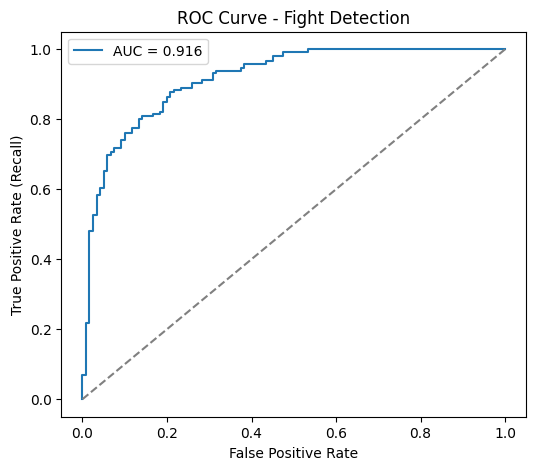

In [ ]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr_curve, tpr_curve, thresholds_curve = roc_curve(y_val, y_pred_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr_curve, tpr_curve, label=f"AUC = 0.916")
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve - Fight Detection")
plt.legend()
plt.savefig("/content/roc_curve.png")
plt.show()

In [ ]:
from tensorflow.keras.models import load_model

best_model = load_model("/content/pose_sequences/best_fight_gru.h5")
best_model.save("/content/pose_sequences/fight_gru_final.keras")

print("Saved in modern Keras format.")

Saved in modern Keras format.


# **Export**

In [ ]:
from google.colab import files

files.download("/content/pose_sequences/fight_gru_final.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download("/content/yolo11n-pose.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
files.download("/content/pose_sequences/best_fight_gru.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>